In [ ]:
from pathlib import Path
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

#Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



#Data Augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])



#Dataset
data_dir = Path(r"C:\FoodTest1\FoodTest1_split_224")

train_dataset = datasets.ImageFolder(data_dir / "train", transform=train_transform)
val_dataset   = datasets.ImageFolder(data_dir / "val", transform=val_transform)
test_dataset  = datasets.ImageFolder(data_dir / "test", transform=val_transform)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))



#Dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)



#Setting Resnet18 model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block (better performance)
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace final fully connected layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(train_dataset.classes))

model = model.to(device)

#Loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3}
])



#Training
MAX_EPOCHS = 20
epoch = 0
losses = []
best_loss = float("inf")
best_val_acc = 0.0

if device.type == "cuda":
    torch.cuda.synchronize()
start_time = time.perf_counter()

while epoch < MAX_EPOCHS:
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / train_total
    train_acc = train_correct / train_total
    losses.append(epoch_loss)

    if epoch_loss < best_loss:
        best_loss = epoch_loss



    #Validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = val_correct / val_total

    #Save the best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet18.pth")

    print(
        f"Epoch {epoch:3d} | "
        f"loss {epoch_loss:.4f} | "
        f"train_acc {train_acc:.4f} | "
        f"val_acc {val_acc:.4f}"
    )

    epoch += 1

if device.type == "cuda":
    torch.cuda.synchronize()
end_time = time.perf_counter()

print("Training complete.")
print(f"Best training loss: {best_loss:.4f}")
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Training took {end_time - start_time:.4f} seconds")

Using device: cuda
Train size: 1392
Val size: 300
Test size: 300
Epoch   0 | loss 2.7806 | train_acc 0.3261 | val_acc 0.5600
Epoch   1 | loss 1.1223 | train_acc 0.7917 | val_acc 0.6833
Epoch   2 | loss 0.5400 | train_acc 0.9109 | val_acc 0.7400
Epoch   3 | loss 0.2905 | train_acc 0.9655 | val_acc 0.7667
Epoch   4 | loss 0.1671 | train_acc 0.9899 | val_acc 0.7767
Epoch   5 | loss 0.1039 | train_acc 0.9950 | val_acc 0.7767
Epoch   6 | loss 0.0702 | train_acc 0.9957 | val_acc 0.7733
Epoch   7 | loss 0.0502 | train_acc 0.9957 | val_acc 0.7800
Epoch   8 | loss 0.0371 | train_acc 0.9971 | val_acc 0.7767
Epoch   9 | loss 0.0334 | train_acc 0.9971 | val_acc 0.7800
Epoch  10 | loss 0.0261 | train_acc 0.9964 | val_acc 0.7700
Epoch  11 | loss 0.0253 | train_acc 0.9964 | val_acc 0.7833
Epoch  12 | loss 0.0224 | train_acc 0.9957 | val_acc 0.7867
Epoch  13 | loss 0.0220 | train_acc 0.9964 | val_acc 0.7767
Epoch  14 | loss 0.0152 | train_acc 0.9986 | val_acc 0.7900
Epoch  15 | loss 0.0159 | train_acc

In [ ]:
#Load the best model
model.load_state_dict(torch.load("best_resnet18.pth"))
model.eval()

all_preds = []
all_labels = []

test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 83.33%


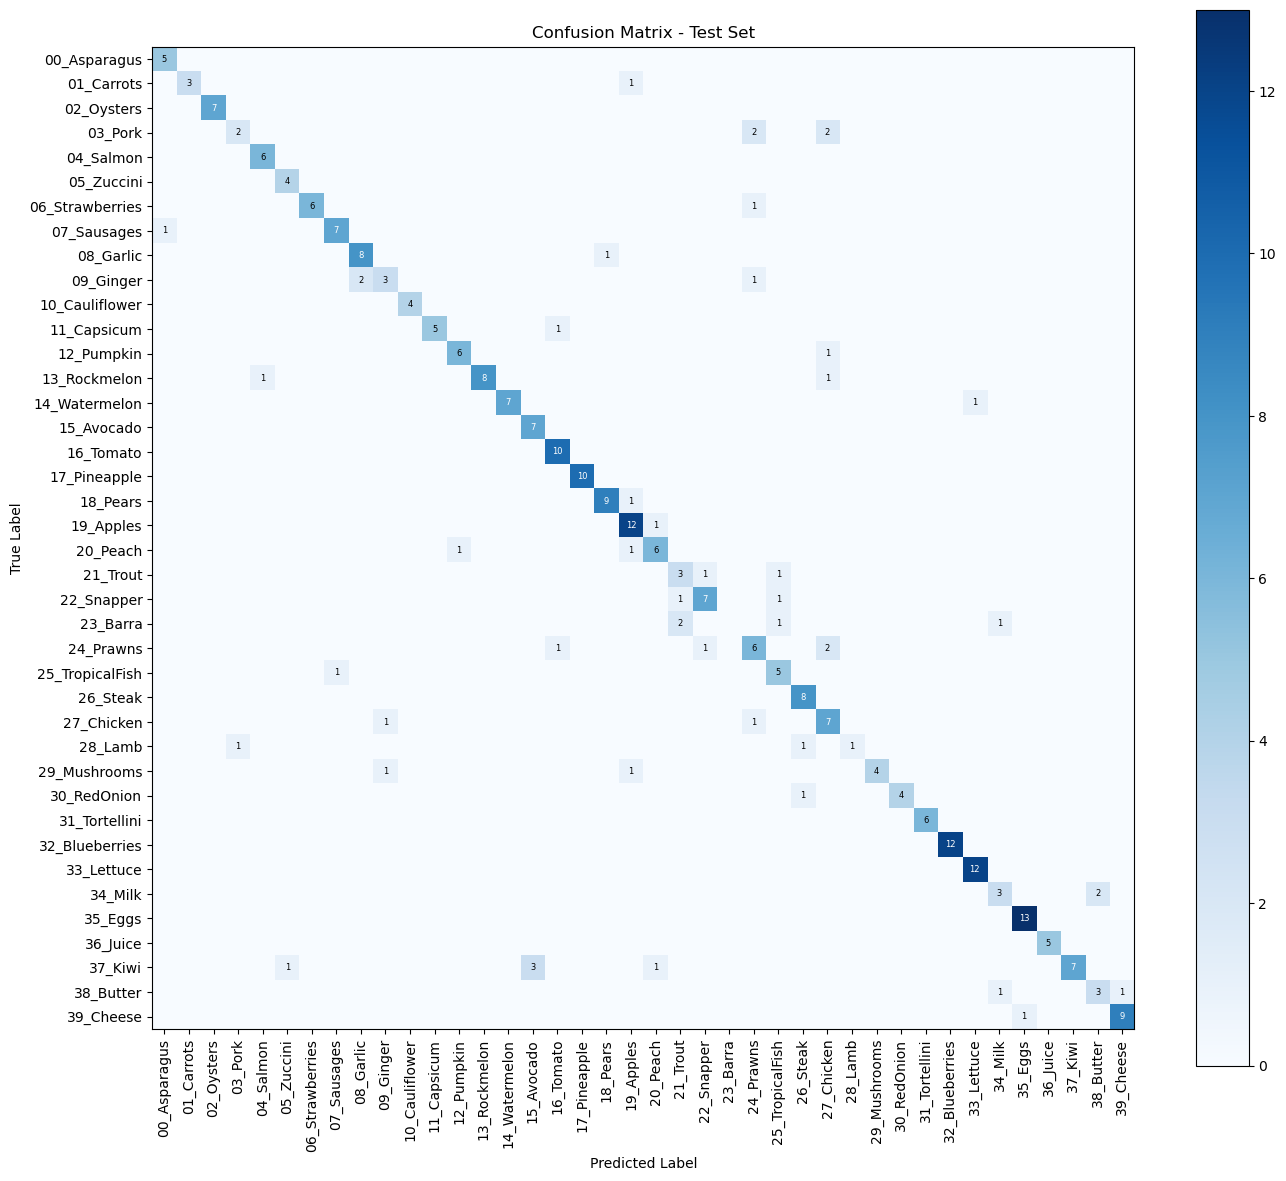

In [ ]:
#Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

classes = test_dataset.classes
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes, rotation=90)
plt.yticks(tick_marks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        if value > 0:
            plt.text(
                j, i, str(value),
                ha="center",
                va="center",
                color="white" if value > cm.max() / 2 else "black",
                fontsize=6
            )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

In [ ]:
#Test evaluation for each class
print("\nLoading best model for test evaluation...")
model.load_state_dict(torch.load("best_resnet18.pth", map_location=device))
model.eval()

class_total = [0] * len(test_dataset.classes)
class_correct = [0] * len(test_dataset.classes)
total_correct = 0
total_samples = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)

        for label, pred in zip(labels, predicted):
            label_idx = label.item()
            pred_idx = pred.item()

            class_total[label_idx] += 1
            if label_idx == pred_idx:
                class_correct[label_idx] += 1

# Output formatting
print(f"\nDataset: {data_dir / 'test'}")
print(f"{'Class':<20} {'Samples':<8} {'Correct':<8} {'Accuracy'}")

accuracies = []
for i, class_name in enumerate(test_dataset.classes):
    samples = class_total[i]
    correct = class_correct[i]
    acc = (correct / samples * 100) if samples > 0 else 0.0
    accuracies.append(acc)
    print(f"{class_name:<20} {samples:<8} {correct:<8} {acc:.2f}%")

mean_class_acc = sum(accuracies) / len(accuracies)
overall_acc = (total_correct / total_samples * 100) if total_samples > 0 else 0.0

print("-" * 50)
print(f"Mean Class Acc: {mean_class_acc:.2f}%")
print(f"Overall Acc: {overall_acc:.2f}%")


Loading best model for test evaluation...

Dataset: C:\MOAD\MOAD_split_224\test
Class                Samples  Correct  Accuracy
00_Asparagus         5        5        100.00%
01_Carrots           4        3        75.00%
02_Oysters           7        6        85.71%
03_Pork              6        2        33.33%
04_Salmon            6        6        100.00%
05_Zuccini           4        4        100.00%
06_Strawberries      7        6        85.71%
07_Sausages          8        6        75.00%
08_Garlic            9        9        100.00%
09_Ginger            4        0        0.00%
10_Cauliflower       4        2        50.00%
11_Capsicum          6        4        66.67%
12_Pumpkin           7        6        85.71%
13_Rockmelon         10       10       100.00%
14_Watermelon        8        7        87.50%
15_Avocado           7        6        85.71%
16_Tomato            10       9        90.00%
17_Pineapple         10       10       100.00%
18_Pears             10       10      